# **Lab 2 DL**
- Sử dụng cùng bộ dữ liệu (CIFA100) cho bài toán image classification. Lựa chọn model FCN/MLP, kết hợp với:

  1. Sử dụng optimizer là Adam. Chia thành 10 batch (tự điều chỉnh batch_size), cố định learning_rate = 1e-3.
  2. Sử dụng Adam Momentum với learning_rate điều chỉnh theo hàm cosin.
  3. Sử dụng optimizer là Quasi-Newton
- Tổng hợp kết quả dưới dạng bảng (acc, f1, ...)



In [1]:
from typing import Any

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, f1_score, precision_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
import matplotlib.pyplot as plt
import random
import time
import torchvision.transforms as transforms
import torch.optim as optim

RANDOM_STATE = 42
# TRAIN_SAMPLES = 8000
# TEST_SAMPLES = 2000

DATA_DIR = "./data"
BATCH_SIZE = 5000
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def set_seed(seed):
    """Khóa toàn bộ seed của Python, Numpy và PyTorch để tái lập kết quả."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(RANDOM_STATE)
print(f"Đã khóa seed = {RANDOM_STATE} thành công.")
print(DEVICE)

Đã khóa seed = 42 thành công.
cpu


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

In [ ]:
def load_cifar100(data_dir=None, batch_size=10):
    """Load CIFAR-100 dataset và trả về DataLoader cho train/test."""
    train_set = datasets.CIFAR100(root=data_dir, train=True, download=True, transform=transform)
    test_set = datasets.CIFAR100(root=data_dir, train=False, download=True, transform=transform)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

    print(f"Đã tạo DataLoader!")
    print(f"- Train batches: {len(train_loader)} (Batch size: {batch_size})")
    print(f"- Test batches: {len(test_loader)} (Batch size: {batch_size})")

    return train_loader, test_loader

In [ ]:
train_loader, test_loader = load_cifar100(data_dir=DATA_DIR, batch_size=BATCH_SIZE)
print(f"Train shape: {train_loader}, Test shape: {test_loader}")
print("Load sucessfull")

100%|██████████| 169M/169M [00:11<00:00, 14.3MB/s]


Đã tạo DataLoader!
- Train batches: 10 (Batch size: 5000)
- Test batches: 2 (Batch size: 5000)
Train shape: <torch.utils.data.dataloader.DataLoader object at 0x7acffafc8bc0>, Test shape: <torch.utils.data.dataloader.DataLoader object at 0x7acffb0b2f90>
Load sucessfull


In [ ]:
class MLP(nn.Module):
    def __init__(self, input_shape=(3, 32, 32), num_classes=100):
        super(MLP, self).__init__()

        if isinstance(input_shape, (tuple, list)):
            self.input_size = torch.prod(torch.tensor(input_shape)).item()
        else:
            self.input_size = input_shape

        self.flatten = nn.Flatten()

        self.net = nn.Sequential(
            nn.Linear(self.input_size, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

In [ ]:
def train_model(model, train_loader, criterion, optimizer, epochs, device, scheduler=None):
    """
    Hàm huấn luyện mô hình linh hoạt hỗ trợ các loại Optimizer và Scheduler khác nhau.
    """
    model.to(device)
    history = {'loss': [], 'acc': []}

    print(f"Bắt đầu training với {type(optimizer).__name__}...")
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # --- XỬ LÝ RIÊNG CHO LBFGS (Quasi-Newton) ---
            if isinstance(optimizer, torch.optim.LBFGS):
                def closure():
                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    return loss

                # Step với closure
                loss = optimizer.step(closure)

                # Forward lại một lần không tính gradient để lấy kết quả tính Accuracy
                with torch.no_grad():
                    outputs = model(inputs)

            # --- XỬ LÝ CHO CÁC OPTIMIZER THÔNG THƯỜNG (Adam, SGD,...) ---
            else:
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            # Thống kê
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        # Cập nhật Learning Rate nếu có dùng Scheduler (Case 2)
        if scheduler is not None:
            scheduler.step()

        # Ghi nhận epoch hiện tại
        epoch_loss = running_loss / total
        epoch_acc = correct / total
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)

        # Lấy Learning Rate hiện tại để in ra log (hữu ích cho Case 2)
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch [{epoch+1}/{epochs}] | LR: {current_lr:.6f} | Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")

    total_time = time.time() - start_time
    print(f"Training hoàn tất trong {total_time:.2f} giây.\n")
    return model, history

def predict(model, test_loader, device):
    """
    Hàm dự đoán trên tập test.
    Trả về (y_true, y_pred) để dễ dàng đưa vào thư viện sklearn tính Acc, F1, Precision, Recall.
    """
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, preds = outputs.max(1)

            # Chuyển tensor về CPU và lưu vào list
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

In [ ]:
EPOCHS = 10

criterion = nn.CrossEntropyLoss()

results = {
    "Model_Case": [],
    "Optimizer": [],
    "Test_Accuracy": [],
    "Test_F1_Macro": [],
    "Test_Precision_Macro": []
}

In [ ]:
print("========== CHẠY CASE 1: ADAM - CỐ ĐỊNH LR ==========")

model_1 = MLP().to(DEVICE)
optimizer_1 = optim.Adam(model_1.parameters(), lr=1e-3)

model_1, history_1 = train_model(
    model=model_1,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer_1,
    epochs=EPOCHS,
    device=DEVICE
)

y_true_1, y_pred_1 = predict(model_1, test_loader, DEVICE)
acc_1 = accuracy_score(y_true_1, y_pred_1)
f1_1 = f1_score(y_true_1, y_pred_1, average='macro')
prec_1 = precision_score(y_true_1, y_pred_1, average='macro', zero_division=0)

print(f"\n=> Kết quả Case 1 - Test Acc: {acc_1:.4f} | Test F1: {f1_1:.4f}")

results["Model_Case"].append("Case 1")
results["Optimizer"].append("Adam (LR cố định)")
results["Test_Accuracy"].append(acc_1)
results["Test_F1_Macro"].append(f1_1)
results["Test_Precision_Macro"].append(prec_1)

========== CHẠY CASE 1: ADAM - CỐ ĐỊNH LR ==========
Bắt đầu training với Adam...
Epoch [1/10] | LR: 0.001000 | Loss: 4.1329 | Train Acc: 0.0822
Epoch [2/10] | LR: 0.001000 | Loss: 3.6093 | Train Acc: 0.1638
Epoch [3/10] | LR: 0.001000 | Loss: 3.3859 | Train Acc: 0.2041
Epoch [4/10] | LR: 0.001000 | Loss: 3.2208 | Train Acc: 0.2346
Epoch [5/10] | LR: 0.001000 | Loss: 3.0831 | Train Acc: 0.2585
Epoch [6/10] | LR: 0.001000 | Loss: 2.9557 | Train Acc: 0.2837
Epoch [7/10] | LR: 0.001000 | Loss: 2.8315 | Train Acc: 0.3095
Epoch [8/10] | LR: 0.001000 | Loss: 2.7220 | Train Acc: 0.3323
Epoch [9/10] | LR: 0.001000 | Loss: 2.6141 | Train Acc: 0.3541
Epoch [10/10] | LR: 0.001000 | Loss: 2.5065 | Train Acc: 0.3787
Training hoàn tất trong 197.21 giây.


=> Kết quả Case 1 - Test Acc: 0.2590 | Test F1: 0.2480


In [ ]:
print("========== CHẠY CASE 2: ADAM MOMENTUM + COSINE LR ==========")

model_2 = MLP().to(DEVICE)
optimizer_2 = optim.Adam(model_2.parameters(), lr=1e-3, betas=(0.9, 0.999))
scheduler_2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_2, T_max=EPOCHS)

model_2, history_2 = train_model(
    model=model_2,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer_2,
    epochs=EPOCHS,
    device=DEVICE,
    scheduler=scheduler_2
)

y_true_2, y_pred_2 = predict(model_2, test_loader, DEVICE)
acc_2 = accuracy_score(y_true_2, y_pred_2)
f1_2 = f1_score(y_true_2, y_pred_2, average='macro')
prec_2 = precision_score(y_true_2, y_pred_2, average='macro', zero_division=0)

print(f"\n=> Kết quả Case 2 - Test Acc: {acc_2:.4f} | Test F1: {f1_2:.4f}")

results["Model_Case"].append("Case 2")
results["Optimizer"].append("Adam + Cosine LR")
results["Test_Accuracy"].append(acc_2)
results["Test_F1_Macro"].append(f1_2)
results["Test_Precision_Macro"].append(prec_2)

========== CHẠY CASE 2: ADAM MOMENTUM + COSINE LR ==========
Bắt đầu training với Adam...
Epoch [1/10] | LR: 0.000976 | Loss: 4.1181 | Train Acc: 0.0849
Epoch [2/10] | LR: 0.000905 | Loss: 3.6023 | Train Acc: 0.1643
Epoch [3/10] | LR: 0.000794 | Loss: 3.3812 | Train Acc: 0.2035
Epoch [4/10] | LR: 0.000655 | Loss: 3.2250 | Train Acc: 0.2340
Epoch [5/10] | LR: 0.000500 | Loss: 3.0978 | Train Acc: 0.2583
Epoch [6/10] | LR: 0.000345 | Loss: 2.9962 | Train Acc: 0.2792
Epoch [7/10] | LR: 0.000206 | Loss: 2.9151 | Train Acc: 0.2947
Epoch [8/10] | LR: 0.000095 | Loss: 2.8561 | Train Acc: 0.3094
Epoch [9/10] | LR: 0.000024 | Loss: 2.8174 | Train Acc: 0.3188
Epoch [10/10] | LR: 0.000000 | Loss: 2.7974 | Train Acc: 0.3234
Training hoàn tất trong 198.34 giây.


=> Kết quả Case 2 - Test Acc: 0.2466 | Test F1: 0.2306


In [ ]:
print("========== CHẠY CASE 3: QUASI-NEWTON (LBFGS) ==========")

model_3 = MLP().to(DEVICE)
# LBFGS thường cần LR ban đầu lớn hơn Adam một chút
optimizer_3 = optim.LBFGS(model_3.parameters(), lr=0.1)

model_3, history_3 = train_model(
    model=model_3,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer_3,
    epochs=EPOCHS,
    device=DEVICE
)

y_true_3, y_pred_3 = predict(model_3, test_loader, DEVICE)
acc_3 = accuracy_score(y_true_3, y_pred_3)
f1_3 = f1_score(y_true_3, y_pred_3, average='macro')
prec_3 = precision_score(y_true_3, y_pred_3, average='macro', zero_division=0)

print(f"\n=> Kết quả Case 3 - Test Acc: {acc_3:.4f} | Test F1: {f1_3:.4f}")

results["Model_Case"].append("Case 3")
results["Optimizer"].append("LBFGS (Quasi-Newton)")
results["Test_Accuracy"].append(acc_3)
results["Test_F1_Macro"].append(f1_3)
results["Test_Precision_Macro"].append(prec_3)

========== CHẠY CASE 3: QUASI-NEWTON (LBFGS) ==========
Bắt đầu training với LBFGS...
Epoch [1/10] | LR: 0.100000 | Loss: 3.7519 | Train Acc: 0.2674
Epoch [2/10] | LR: 0.100000 | Loss: 3.1436 | Train Acc: 0.4918
Epoch [3/10] | LR: 0.100000 | Loss: 2.6741 | Train Acc: 0.6218
Epoch [4/10] | LR: 0.100000 | Loss: 2.3245 | Train Acc: 0.6961
Epoch [5/10] | LR: 0.100000 | Loss: 2.1007 | Train Acc: 0.7396
Epoch [6/10] | LR: 0.100000 | Loss: 1.9466 | Train Acc: 0.7717
Epoch [7/10] | LR: 0.100000 | Loss: 1.8176 | Train Acc: 0.8005
Epoch [8/10] | LR: 0.100000 | Loss: 1.7159 | Train Acc: 0.8216
Epoch [9/10] | LR: 0.100000 | Loss: 1.5957 | Train Acc: 0.8406
Epoch [10/10] | LR: 0.100000 | Loss: 1.5007 | Train Acc: 0.8581
Training hoàn tất trong 3496.53 giây.


=> Kết quả Case 3 - Test Acc: 0.2643 | Test F1: 0.2611


In [ ]:
df_results = pd.DataFrame(results)

print("============ BẢNG TỔNG HỢP KẾT QUẢ ============\n")
display(df_results)

============ BẢNG TỔNG HỢP KẾT QUẢ ============



,Model_Case,Optimizer,Test_Accuracy,Test_F1_Macro,Test_Precision_Macro
0,Case 1,Adam (LR cố định),0.2590,0.247956,0.259185
1,Case 2,Adam + Cosine LR,0.2466,0.230570,0.229964
2,Case 3,LBFGS (Quasi-Newton),0.2643,0.261130,0.264961


In [ ]:
# Lấy danh sách tên các lớp (classes) của CIFAR100
classes = test_loader.dataset.classes

def imshow(img):
    """Hàm để un-normalize và hiển thị ảnh"""
    img = img.numpy().transpose((1, 2, 0))
    # Các thông số normalize đã dùng ở trên
    mean = np.array([0.5071, 0.4867, 0.4408])
    std = np.array([0.2675, 0.2565, 0.2761])
    # Un-normalize: x = z * std + mean
    img = std * img + mean
    img = np.clip(img, 0, 1) # Giới hạn giá trị pixel trong khoảng [0, 1]
    plt.imshow(img)

def visualize_demo(model, test_loader, num_images=5):
    """Hàm lấy ra num_images ảnh và hiển thị kết quả dự đoán"""
    model.eval()
    dataiter = iter(test_loader)
    images, labels = next(dataiter)

    # Chuyển data sang DEVICE (GPU/CPU)
    images = images.to(DEVICE)
    labels = labels.to(DEVICE)

    # Dự đoán
    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

    # Chuyển ngược lại CPU để vẽ hình
    images = images.cpu()
    labels = labels.cpu()
    predicted = predicted.cpu()

    # Plot hình
    fig = plt.figure(figsize=(15, 4))
    for idx in range(num_images):
        ax = fig.add_subplot(1, num_images, idx + 1, xticks=[], yticks=[])
        imshow(images[idx])

        true_label = classes[labels[idx]]
        pred_label = classes[predicted[idx]]

        # Tiêu đề: True label / Predicted label
        title_text = f"True: {true_label}\nPred: {pred_label}"
        color = "green" if true_label == pred_label else "red"
        ax.set_title(title_text, color=color, fontsize=10)

    plt.tight_layout()
    plt.show()

====== DEMO PREDICTIONS (MODEL 1) ======


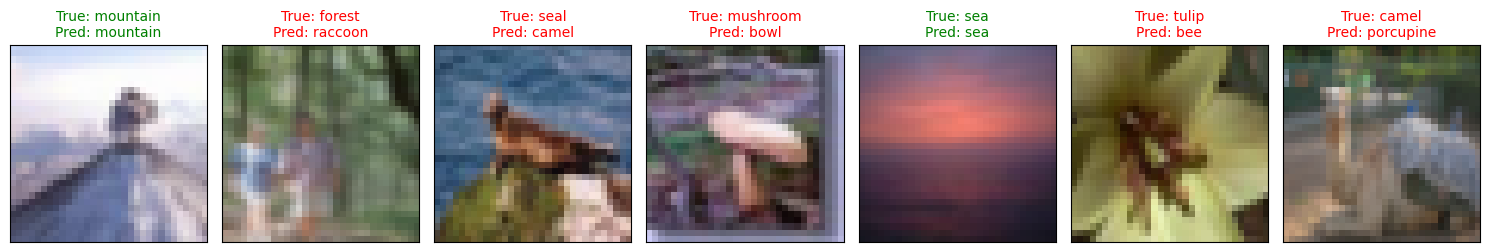

In [ ]:
# Hiển thị demo 5 ảnh với Model 1
print("====== DEMO PREDICTIONS (MODEL 1) ======")
visualize_demo(model_1, test_loader, num_images=7)

====== DEMO PREDICTIONS (MODEL 2) ======


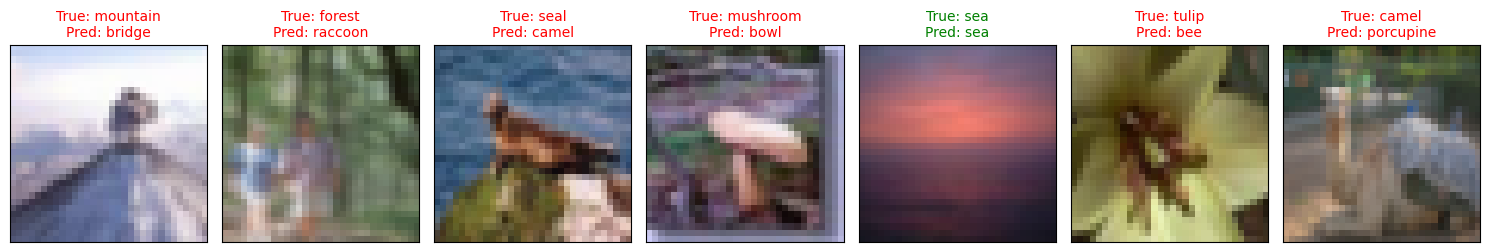

In [ ]:
# Hiển thị demo 5 ảnh với Model 2
print("====== DEMO PREDICTIONS (MODEL 2) ======")
visualize_demo(model_2, test_loader, num_images=7)

====== DEMO PREDICTIONS (MODEL 3) ======


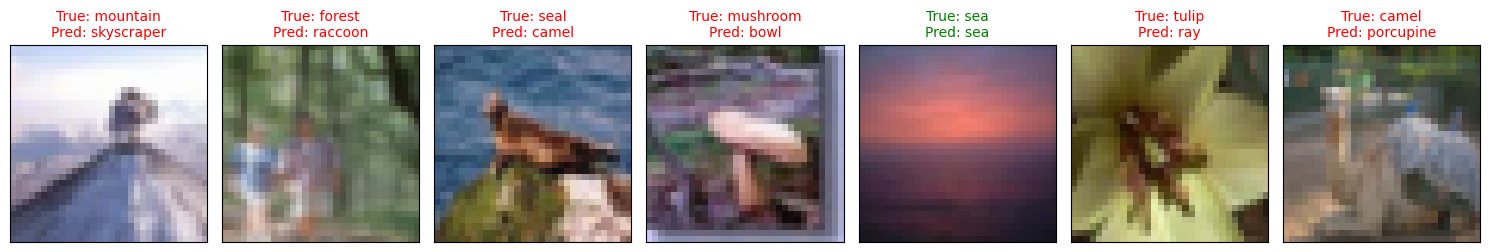

In [ ]:
# Hiển thị demo 5 ảnh với Model 3
print("====== DEMO PREDICTIONS (MODEL 3) ======")
visualize_demo(model_3, test_loader, num_images=7)